# Exploratory Data Analysis on final_df

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
final_df = pd.read_csv("final_df.csv")

In [3]:
final_df.head(4)

,match_id,ball,city,batting_team,toss_decision,target,bowling_team,current_score,runs_left,balls_left,wickets_left,crr,rrr,result
0,153,1,Port Elizabeth,Royal Challengers Bangalore,bat,157,Mumbai Indians,44,114,77,7,6.139535,8.883117,0
1,139,3,Durban,Kings XI Punjab,bat,145,Royal Challengers Bangalore,97,49,27,7,6.258065,10.888889,0
2,7944,7,Bengaluru,Sunrisers Hyderabad,field,222,Royal Challengers Bangalore,187,36,11,8,10.293578,19.636364,0
3,7937,6,Indore,Kings XI Punjab,field,250,Kolkata Knight Riders,129,122,42,5,9.923077,17.428571,0


In [4]:
final_df.info()
final_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48777 entries, 0 to 48776
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   match_id       48777 non-null  int64  
 1   ball           48777 non-null  int64  
 2   city           48777 non-null  object 
 3   batting_team   48777 non-null  object 
 4   toss_decision  48777 non-null  object 
 5   target         48777 non-null  int64  
 6   bowling_team   48777 non-null  object 
 7   current_score  48777 non-null  int64  
 8   runs_left      48777 non-null  int64  
 9   balls_left     48777 non-null  int64  
 10  wickets_left   48777 non-null  int64  
 11  crr            48777 non-null  float64
 12  rrr            48777 non-null  float64
 13  result         48777 non-null  int64  
dtypes: float64(2), int64(8), object(4)
memory usage: 5.2+ MB


,match_id,ball,target,current_score,runs_left,balls_left,wickets_left,crr,rrr,result
count,48777.00000,48777.000000,48777.000000,48777.000000,48777.000000,48777.000000,48777.000000,48777.000000,48777.000000,48777.000000
mean,2719.81233,3.602907,167.562294,73.671731,94.890563,62.719007,7.576747,7.478781,10.798054,0.536216
std,4199.86732,1.806160,29.550160,47.271160,50.513768,33.306527,2.127366,2.302292,14.923794,0.498692
min,1.00000,1.000000,67.000000,0.000000,-15.000000,-2.000000,0.000000,0.000000,-516.000000,0.000000
25%,228.00000,2.000000,148.000000,34.000000,55.000000,35.000000,6.000000,6.276923,7.333333,0.000000
50%,457.00000,4.000000,167.000000,70.000000,95.000000,63.000000,8.000000,7.500000,9.101695,1.000000
75%,7894.00000,5.000000,187.000000,109.000000,132.000000,92.000000,9.000000,8.752941,11.225806,1.000000
max,11415.00000,9.000000,250.000000,222.000000,250.000000,119.000000,10.000000,42.000000,684.000000,1.000000


In [5]:
final_df.isnull().sum()

match_id         0
ball             0
city             0
batting_team     0
toss_decision    0
target           0
bowling_team     0
current_score    0
runs_left        0
balls_left       0
wickets_left     0
crr              0
rrr              0
result           0
dtype: int64

**Target Variable Analysis (Win vs Loss)**

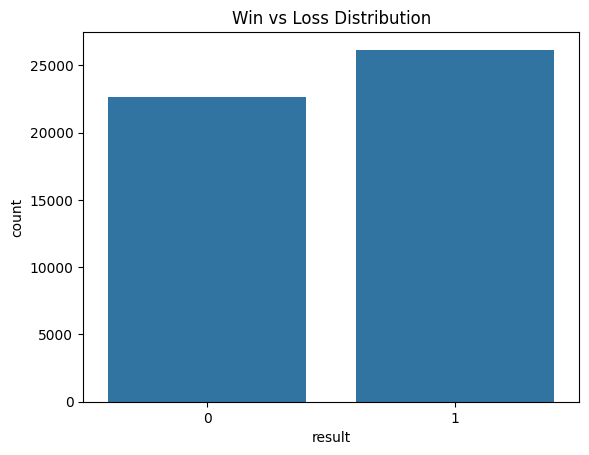

In [6]:
sns.countplot(x='result', data=final_df)
plt.title("Win vs Loss Distribution")
plt.show()

**Runs Left vs Result**

In [7]:
temp_df = final_df.groupby('runs_left')['result'].mean().reset_index()

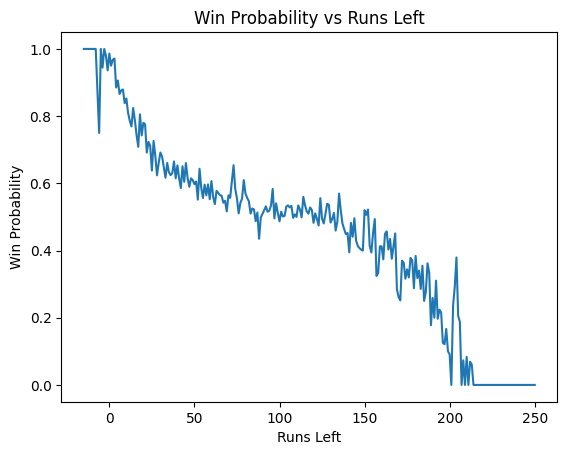

In [8]:
plt.plot(temp_df['runs_left'], temp_df['result'])
plt.xlabel("Runs Left")
plt.ylabel("Win Probability")
plt.title("Win Probability vs Runs Left")
plt.show()

**Toss decision & city vs Result**

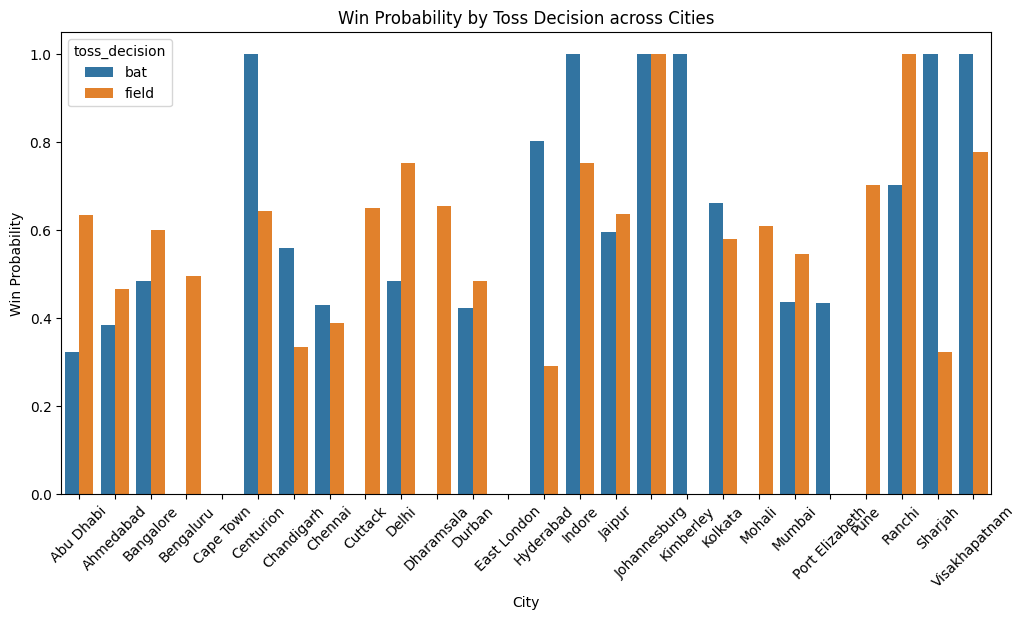

In [9]:
temp_df = final_df.groupby(['city', 'toss_decision'])['result'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(x='city', y='result', hue='toss_decision', data=temp_df)

plt.title("Win Probability by Toss Decision across Cities")
plt.xlabel("City")
plt.ylabel("Win Probability")
plt.xticks(rotation=45)
plt.show()

**Balls Left vs Result**

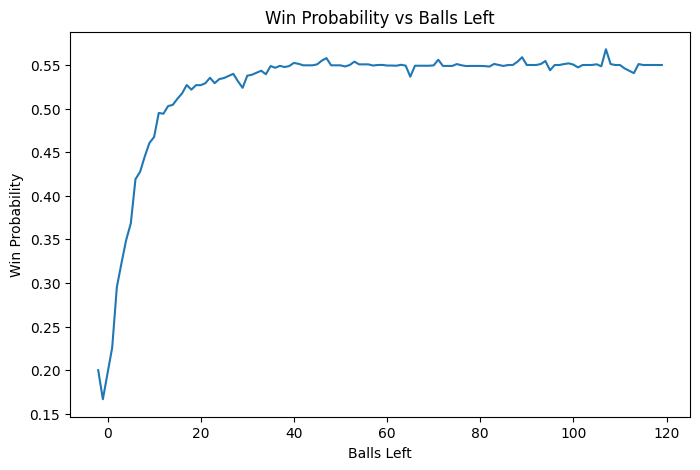

In [10]:
temp_df = final_df.groupby('balls_left')['result'].mean().reset_index()

plt.figure(figsize=(8,5))
plt.plot(temp_df['balls_left'], temp_df['result'])
plt.xlabel("Balls Left")
plt.ylabel("Win Probability")
plt.title("Win Probability vs Balls Left")
plt.show()

**Wickets Left vs Result**

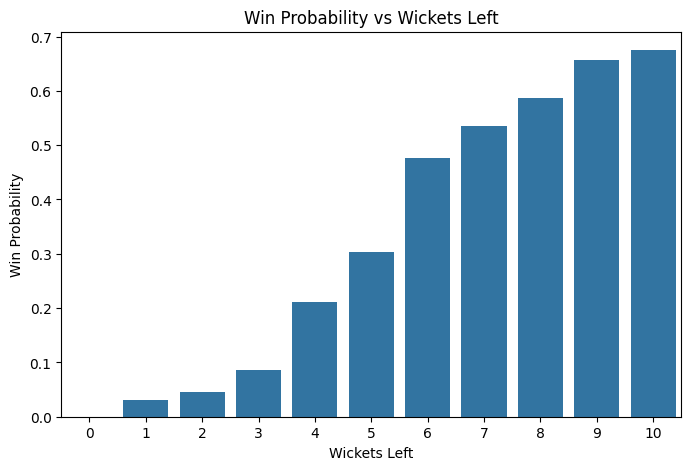

In [11]:
temp_df = final_df.groupby('wickets_left')['result'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='wickets_left', y='result', data=temp_df)

plt.xlabel("Wickets Left")
plt.ylabel("Win Probability")
plt.title("Win Probability vs Wickets Left")
plt.show()

**Current Run Rate (CRR) vs Result**

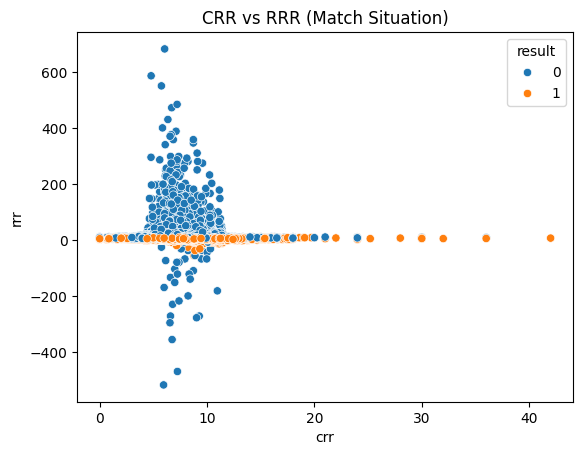

In [12]:
sns.scatterplot(x='crr', y='rrr', hue='result', data=final_df)
plt.title("CRR vs RRR (Match Situation)")
plt.show()

**Correlation Heatmap**

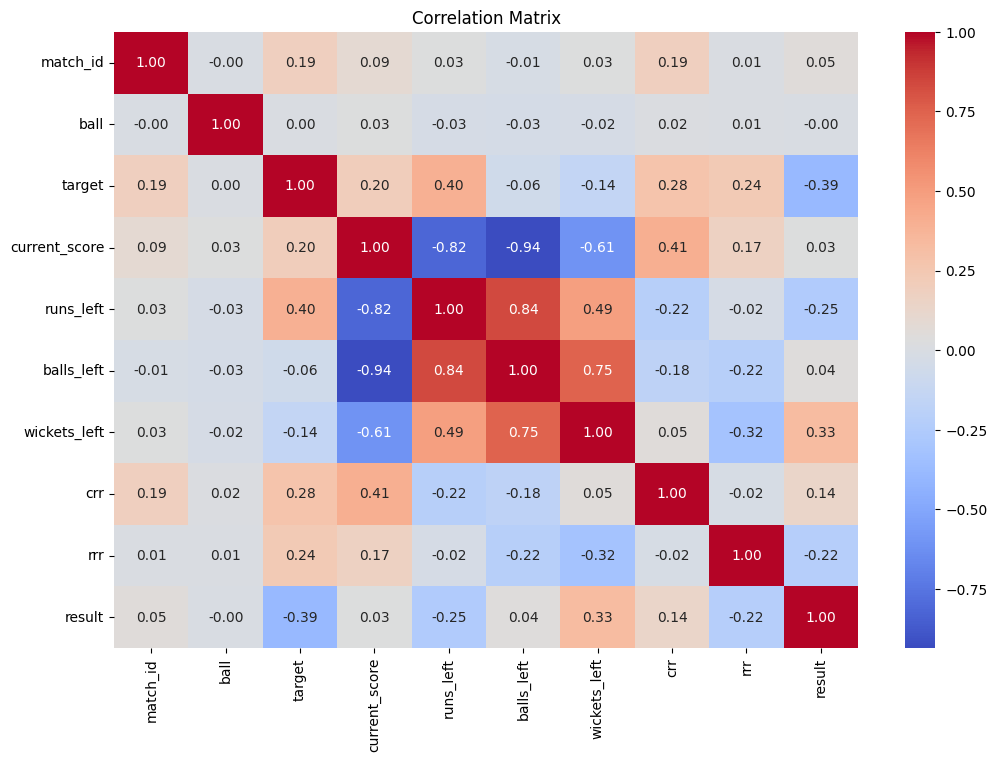

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(final_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

**Team Performance Analysis**

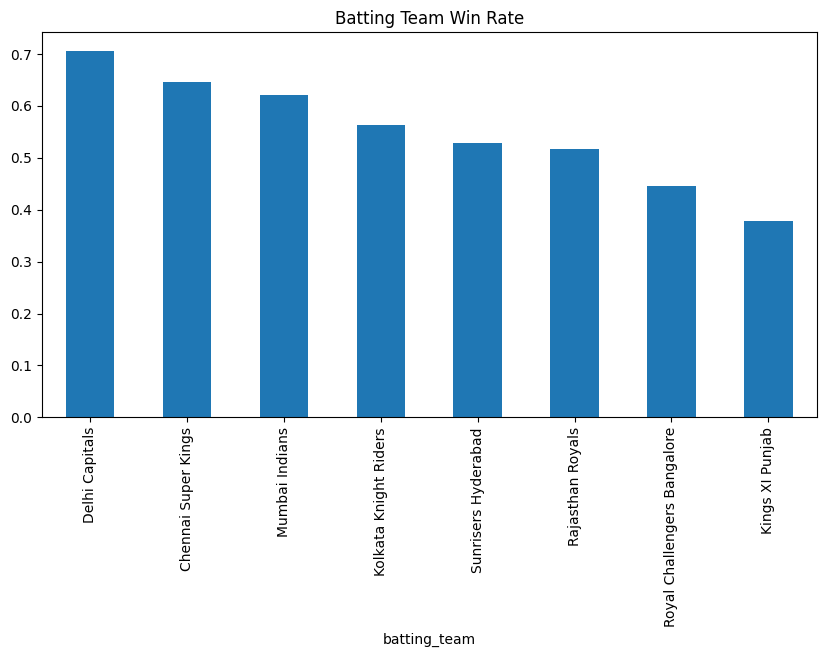

In [14]:
team_win = final_df.groupby('batting_team')['result'].mean().sort_values(ascending=False)

team_win.plot(kind='bar', figsize=(10,5))
plt.title("Batting Team Win Rate")
plt.show()

**City (Venue) Analysis**

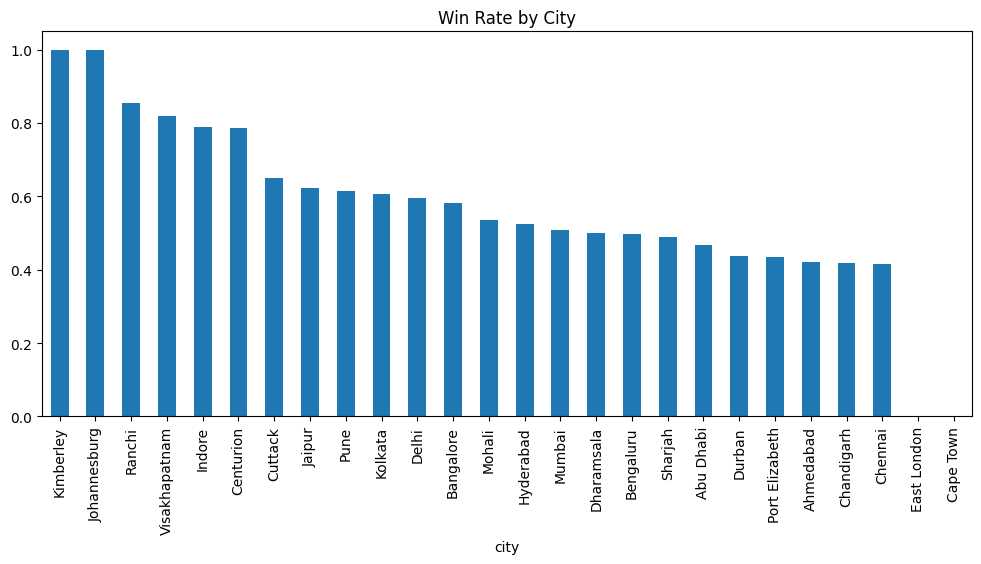

In [15]:
city_win = final_df.groupby('city')['result'].mean().sort_values(ascending=False)

city_win.plot(kind='bar', figsize=(12,5))
plt.title("Win Rate by City")
plt.show()

**Match Pressure Analysis**

In [16]:
final_df['pressure'] = final_df['runs_left'] / final_df['balls_left']

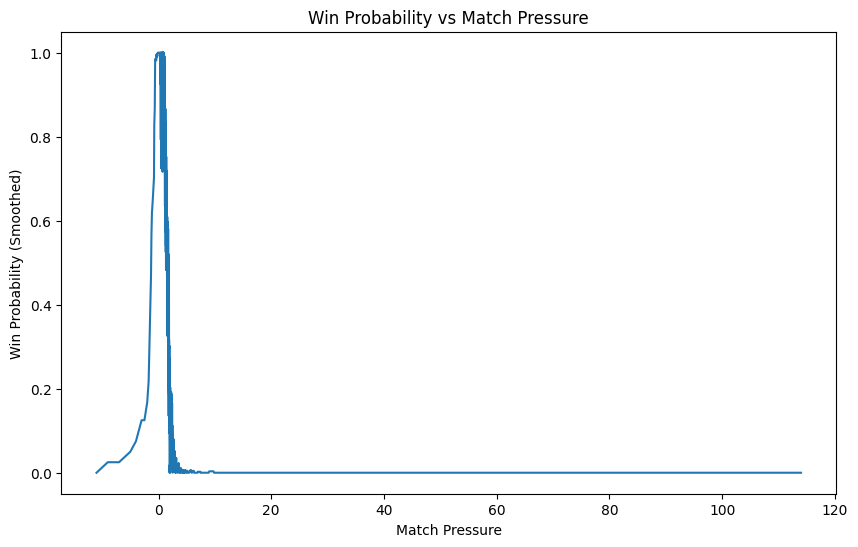

In [17]:
temp_df = final_df.groupby('pressure')['result'].mean().reset_index()
temp_df = temp_df.sort_values('pressure')
temp_df['smoothed'] = temp_df['result'].rolling(window=20).mean()

plt.figure(figsize=(10,6))
plt.plot(temp_df['pressure'], temp_df['smoothed'])
plt.xlabel("Match Pressure")
plt.ylabel("Win Probability (Smoothed)")
plt.title("Win Probability vs Match Pressure")
plt.show()

**Distribution Plots**

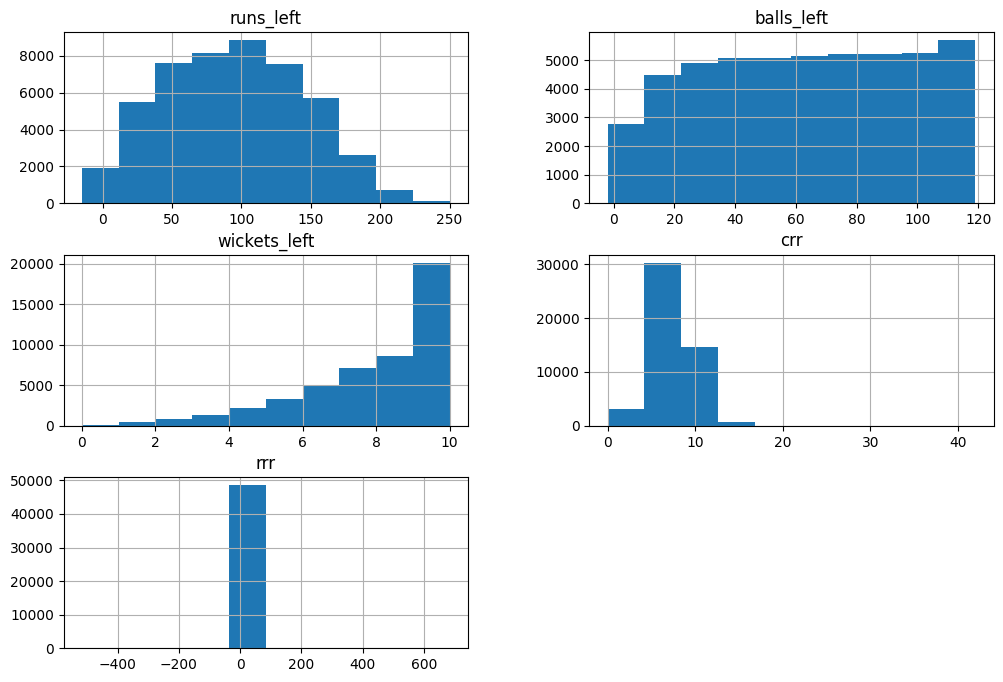

In [18]:
final_df[['runs_left','balls_left','wickets_left','crr','rrr']].hist(figsize=(12,8))
plt.show()

**Pairplot**

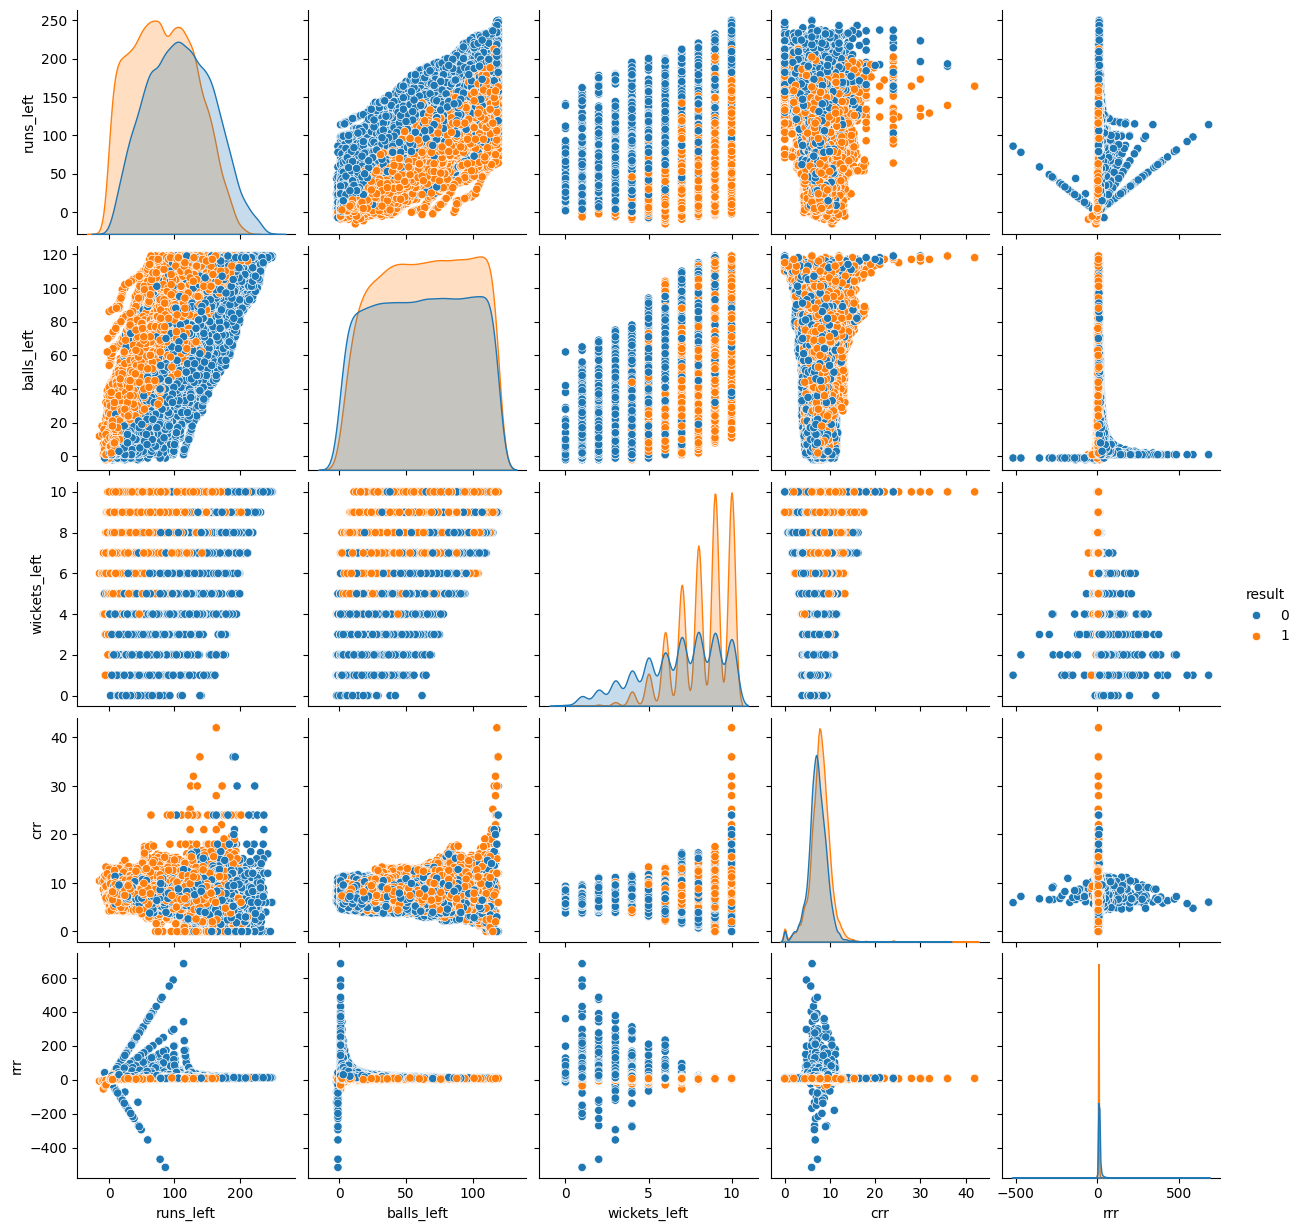

In [19]:
sns.pairplot(final_df[['runs_left','balls_left','wickets_left','crr','rrr','result']], hue='result')
plt.show()